<a href="https://colab.research.google.com/github/camilousta02-crypto/proyecto_final_Velandia_Camilo/blob/main/%20bloque3_nlp/bloque3_nlp_Velandia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# CELDA 0: Instalación y configuración
# ============================================

!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install -q pyspark==3.5.0 findspark pandas matplotlib seaborn
!pip install -q transformers datasets

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import *
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

from transformers import pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder.appName("SIPSA_NLP").getOrCreate()
print("✅ Spark + Transformers listos")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.
✅ Spark + Transformers listos


# PARTE A: PREPARACIÓN DEL CORPUS (Tareas 21-24)

In [ ]:
# ============================================
# TAREA 21: Cargar corpus textual colombiano
# ============================================

print("=" * 70)
print("PARTE A - TAREA 21: CORPUS TEXTUAL")
print("=" * 70)

# OPCIÓN 1: Usar descripciones de productos del SIPSA (mínimo 200 documentos)
# El corpus son las combinaciones de Producto + Variedad + Grupo

# Cargar datos SIPSA
ruta_dataset = "/content/drive/MyDrive/Marchine learning/BaseDatos-SIPSA_P-Mensual-2013_2017/Mensual_2013_2017.csv"
df_sipsa = spark.read.csv(ruta_dataset, header=True, inferSchema=True, sep=";", encoding="ISO-8859-1")

# Crear documentos de texto a partir de las descripciones de productos
df_corpus = df_sipsa.select(
    F.concat_ws(" ", F.col("Producto"), F.col("Grupo")).alias("texto"),
    F.col("Grupo").alias("categoria"),
    F.col("Precio")
).dropDuplicates(["texto"])

n_docs = df_corpus.count()
print(f"📄 Documentos en corpus (SIPSA): {n_docs:,}")

# Si necesitas más volumen, complementar con corpus externo:
# OPCIÓN 2: Descargar tweets/noticias agrícolas (opcional)
# from datasets import load_dataset
# corpus_externo = load_dataset("sentiment_analysis_spanish", split="train")

# Verificar mínimo 200 documentos
if n_docs >= 200:
    print(f"✅ Cumple requisito mínimo (≥200 documentos)")
else:
    print(f"⚠️ Necesitas más documentos. Considera corpus externo.")

df_corpus.show(10, truncate=False)

PARTE A - TAREA 21: CORPUS TEXTUAL
📄 Documentos en corpus (SIPSA): 379
✅ Cumple requisito mínimo (≥200 documentos)
+---------------------------------------+---------------------+------+
|texto                                  |categoria            |Precio|
+---------------------------------------+---------------------+------+
|Aceite girasol PROCESADOS              |PROCESADOS           |6083  |
|Aceite soya PROCESADOS                 |PROCESADOS           |4336  |
|Aceite vegetal mezcla PROCESADOS       |PROCESADOS           |3847  |
|Acelga VERDURAS Y HORTALIZAS           |VERDURAS Y HORTALIZAS|1467  |
|Aguacate Hass FRUTAS                   |FRUTAS               |2814  |
|Aguacate común FRUTAS                  |FRUTAS               |3917  |
|Aguacate papelillo FRUTAS              |FRUTAS               |2683  |
|Ahuyama VERDURAS Y HORTALIZAS          |VERDURAS Y HORTALIZAS|515   |
|Ahuyamín (Sakata) VERDURAS Y HORTALIZAS|VERDURAS Y HORTALIZAS|439   |
|Ajo VERDURAS Y HORTALIZAS       

In [ ]:
# ============================================
# TAREA 22: Tokenización y filtrado de stop words
# ============================================

print("\n" + "=" * 70)
print("PARTE A - TAREA 22: TOKENIZACIÓN Y STOP WORDS")
print("=" * 70)

# RegexTokenizer
tokenizer = RegexTokenizer(
    inputCol="texto",
    outputCol="tokens_raw",
    pattern="\\W+",  # Separar por caracteres no alfanuméricos
    toLowercase=True,
    gaps=True
)

df_tokens = tokenizer.transform(df_corpus)

# Stop words en español + palabras del dominio agrícola irrelevantes
stopwords_es = StopWordsRemover.loadDefaultStopWords("spanish")
stopwords_dominio = ["kg", "unidad", "presentacion", "tipo", "variedad", "gr", "ml",
                     "lt", "libra", "bolsa", "paquete", "fresco", "congelado"]

remover = StopWordsRemover(
    inputCol="tokens_raw",
    outputCol="tokens",
    stopWords=stopwords_es + stopwords_dominio
)

df_clean = remover.transform(df_tokens)

print("✅ Tokenización completada")
df_clean.select("texto", "tokens_raw", "tokens").show(5, truncate=False)


PARTE A - TAREA 22: TOKENIZACIÓN Y STOP WORDS
✅ Tokenización completada
+-----------------------------------------+-----------------------------------------------+--------------------------------------------+
|texto                                    |tokens_raw                                     |tokens                                      |
+-----------------------------------------+-----------------------------------------------+--------------------------------------------+
|Mandarina Oneco FRUTAS                   |[mandarina, oneco, frutas]                     |[mandarina, oneco, frutas]                  |
|Melón Cantalup FRUTAS                    |[mel, n, cantalup, frutas]                     |[mel, n, cantalup, frutas]                  |
|Maíz blanco trillado GRANOS Y CEREALES   |[ma, z, blanco, trillado, granos, y, cereales] |[ma, z, blanco, trillado, granos, cereales] |
|Tilapia roja entera congelada PESCADOS   |[tilapia, roja, entera, congelada, pescados]   |[tilapia, roja

In [ ]:
# ============================================
# TAREA 23: Estadística descriptiva del corpus
# ============================================

print("\n" + "=" * 70)
print("PARTE A - TAREA 23: ESTADÍSTICA DEL CORPUS")
print("=" * 70)

# Total de tokens
df_clean = df_clean.withColumn("n_tokens", F.size("tokens"))

total_tokens = df_clean.select(F.explode("tokens").alias("token")).count()
vocabulario = df_clean.select(F.explode("tokens").alias("token")).distinct().count()
n_docs = df_clean.count()

# TTR (Type-Token Ratio)
ttr = vocabulario / total_tokens if total_tokens > 0 else 0

print(f"\n📊 Estadísticas del corpus:")
print(f"   Documentos:      {n_docs:,}")
print(f"   Total tokens:    {total_tokens:,}")
print(f"   Vocabulario:     {vocabulario:,}")
print(f"   TTR:             {ttr:.4f}")
print(f"   Tokens/doc (avg):{df_clean.select(F.avg('n_tokens')).collect()[0][0]:.1f}")

# Tokens por documento
df_clean.select(
    F.min("n_tokens").alias("min"),
    F.max("n_tokens").alias("max"),
    F.avg("n_tokens").alias("promedio"),
    F.stddev("n_tokens").alias("desviacion")
).show()


PARTE A - TAREA 23: ESTADÍSTICA DEL CORPUS

📊 Estadísticas del corpus:
   Documentos:      379
   Total tokens:    1,615
   Vocabulario:     410
   TTR:             0.2539
   Tokens/doc (avg):4.3
+---+---+-----------------+-----------------+
|min|max|         promedio|       desviacion|
+---+---+-----------------+-----------------+
|  2| 10|4.261213720316623|1.365814524976452|
+---+---+-----------------+-----------------+



In [ ]:
# ============================================
# TAREA 24: Hapax legomena
# ============================================

print("\n" + "=" * 70)
print("PARTE A - TAREA 24: HAPAX LEGOMENA")
print("=" * 70)

# Frecuencia de cada token
frecuencias = df_clean.select(F.explode("tokens").alias("token")) \
    .groupBy("token").count()

hapax = frecuencias.filter(F.col("count") == 1)
n_hapax = hapax.count()

print(f"   Hapax legomena: {n_hapax:,} ({n_hapax/vocabulario*100:.1f}% del vocabulario)")

# Reflexión
print(f"""
💡 REFLEXIÓN SOBRE HAPAX:
Los hapax representan el {n_hapax/vocabulario*100:.1f}% del vocabulario.
{'Filtrarlos REDUCE ruido' if n_hapax/vocabulario > 0.5 else 'Son minoría, no es crítico filtrar'}
en modelos clásicos (TF-IDF), pero en transformers (Hugging Face)
se mantienen porque el modelo aprende representaciones contextuales.
""")


PARTE A - TAREA 24: HAPAX LEGOMENA
   Hapax legomena: 234 (57.1% del vocabulario)

💡 REFLEXIÓN SOBRE HAPAX:
Los hapax representan el 57.1% del vocabulario. 
Filtrarlos REDUCE ruido 
en modelos clásicos (TF-IDF), pero en transformers (Hugging Face) 
se mantienen porque el modelo aprende representaciones contextuales.



# PARTE B: TF-IDF (Tareas 25-27)

In [ ]:
# ============================================
# TAREA 25: CountVectorizer + IDF
# ============================================

print("\n" + "=" * 70)
print("PARTE B - TAREA 25: TF-IDF")
print("=" * 70)

cv = CountVectorizer(inputCol="tokens", outputCol="tf", minDF=2, vocabSize=5000)
model_cv = cv.fit(df_clean)
df_tf = model_cv.transform(df_clean)

idf = IDF(inputCol="tf", outputCol="tfidf")
model_idf = idf.fit(df_tf)
df_tfidf = model_idf.transform(df_tf)

vocab = model_cv.vocabulary
print(f"✅ TF-IDF completado")
print(f"   Tamaño vocabulario: {len(vocab):,}")

# ============================================
# TAREA 26: Palabras con mayor TF-IDF
# ============================================

print("\n" + "=" * 70)
print("PARTE B - TAREA 26: TOP PALABRAS TF-IDF")
print("=" * 70)

from pyspark.ml.functions import vector_to_array

# Promedio TF-IDF por palabra (muestra para velocidad)
sample_tfidf = df_tfidf.select(vector_to_array("tfidf").alias("tfidf_arr")).sample(False, 0.5, seed=42).toPandas()
tfidf_matrix = np.vstack(sample_tfidf["tfidf_arr"].values)
mean_tfidf = np.mean(tfidf_matrix, axis=0)

top_tfidf = np.argsort(mean_tfidf)[::-1][:20]
print("\nTop 20 palabras por TF-IDF promedio:")
for i, idx in enumerate(top_tfidf, 1):
    print(f"  {i:2d}. {vocab[idx]:25s} {mean_tfidf[idx]:.4f}")

# ============================================
# TAREA 27: Comparar TF crudo vs TF-IDF
# ============================================

print("\n" + "=" * 70)
print("PARTE B - TAREA 27: TF vs TF-IDF")
print("=" * 70)

tf_sums = np.sum(tfidf_matrix > 0, axis=0)
top_tf = np.argsort(tf_sums)[::-1][:10]

print("\nTop 10 por frecuencia (TF):")
for i, idx in enumerate(top_tf, 1):
    print(f"  {i:2d}. {vocab[idx]:25s} {tf_sums[idx]:,} docs")

print("\nTop 10 por TF-IDF:")
for i, idx in enumerate(top_tfidf[:10], 1):
    print(f"  {i:2d}. {vocab[idx]:25s} {mean_tfidf[idx]:.4f}")

print("""
📊 EXPLICACIÓN:
TF crudo favorece palabras frecuentes ('pollo', 'carne').
TF-IDF penaliza palabras comunes y resalta términos discriminativos
específicos de ciertos productos ('costillar', 'hass', 'pastusa').
""")


PARTE B - TAREA 25: TF-IDF
✅ TF-IDF completado
   Tamaño vocabulario: 176

PARTE B - TAREA 26: TOP PALABRAS TF-IDF

Top 20 palabras por TF-IDF promedio:
   1. frutas                    0.3637
   2. raices                    0.3020
   3. platanos                  0.3020
   4. tuberculos                0.3020
   5. hortalizas                0.2990
   6. verduras                  0.2990
   7. n                         0.2868
   8. granos                    0.2361
   9. cereales                  0.2361
  10. pescados                  0.2315
  11. carnes                    0.2253
  12. papa                      0.2083
  13. procesados                0.2007
  14. carne                     0.1792
  15. verde                     0.1749
  16. jol                       0.1538
  17. fr                        0.1538
  18. pl                        0.1368
  19. tano                      0.1368
  20. res                       0.1290

PARTE B - TAREA 27: TF vs TF-IDF

Top 10 por frecuencia (TF):
   

# PARTE C: CLASIFICACIÓN CON TF-IDF (Tareas 28-33)

In [ ]:
# ============================================
# TAREA 28-30: Variable objetivo y split
# ============================================

print("\n" + "=" * 70)
print("PARTE C - TAREAS 28-30: CLASIFICACIÓN TF-IDF")
print("=" * 70)

# Variable objetivo: categoría del producto (Grupo)
indexer_cat = StringIndexer(inputCol="categoria", outputCol="label")
df_labeled = indexer_cat.fit(df_tfidf).transform(df_tfidf)

train_nlp, test_nlp = df_labeled.randomSplit([0.8, 0.2], seed=42)

# ============================================
# TAREA 31: Regresión Logística sobre TF-IDF
# ============================================

lr_nlp = LogisticRegression(featuresCol="tfidf", labelCol="label", maxIter=20, regParam=0.1)
model_lr_nlp = lr_nlp.fit(train_nlp)
pred_nlp = model_lr_nlp.transform(test_nlp)

# ============================================
# TAREA 32: Evaluación
# ============================================

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

print(f"\n📊 Resultados TF-IDF + Regresión Logística:")
print(f"   Accuracy: {evaluator_acc.evaluate(pred_nlp):.4f}")
print(f"   F1-Score: {evaluator_f1.evaluate(pred_nlp):.4f}")

# Matriz de confusión
pred_nlp.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

# ============================================
# TAREA 33: Coeficientes - palabras predictoras por clase (VERSIÓN SEGURA)
# ============================================

print("\n" + "=" * 70)
print("PARTE C - TAREA 33: PALABRAS PREDICTORAS POR CLASE")
print("=" * 70)

# Obtener coeficientes del modelo
coeficientes = model_lr_nlp.coefficientMatrix.toArray()

# Obtener mapeo de clases numéricas → nombres de categorías desde el DataFrame
categorias_df = df_labeled.select("categoria", "label").distinct().orderBy("label").toPandas()
categorias_mapeo = dict(zip(categorias_df["label"], categorias_df["categoria"]))

print(f"📊 Mapeo de clases: {categorias_mapeo}")
print(f"   Total clases: {len(categorias_mapeo)}")
print(f"   Total coeficientes: {len(coeficientes)}")

# Para cada clase, mostrar palabras más predictoras
for i in range(len(coeficientes)):
    cat_nombre = categorias_mapeo.get(float(i), f"Clase_{i}")

    print(f"\n{'='*60}")
    print(f"🔷 CLASE {i}: {cat_nombre}")
    print(f"{'='*60}")

    # Top 10 positivos (predicen esta clase)
    top_pos = np.argsort(coeficientes[i])[-10:]

    # Top 10 negativos (rechazan esta clase)
    top_neg = np.argsort(coeficientes[i])[:10]

    print("\n  Palabras que MÁS predicen esta clase (+):")
    print(f"  {'Rank':>5s} {'Palabra':>25s} {'Coeficiente':>12s}")
    print(f"  {'-'*45}")
    for rank, idx in enumerate(reversed(top_pos), 1):
        if idx < len(vocab):
            print(f"  {rank:>5d} {vocab[idx]:>25s} {coeficientes[i][idx]:>+12.3f}")

    print("\n  Palabras que MENOS predicen esta clase (-):")
    print(f"  {'Rank':>5s} {'Palabra':>25s} {'Coeficiente':>12s}")
    print(f"  {'-'*45}")
    for rank, idx in enumerate(top_neg, 1):
        if idx < len(vocab):
            print(f"  {rank:>5d} {vocab[idx]:>25s} {coeficientes[i][idx]:>+12.3f}")

# Resumen interpretativo
print(f"\n{'='*60}")
print("INTERPRETACIÓN DE COEFICIENTES")
print(f"{'='*60}")
print("""
Los coeficientes positivos indican palabras que aumentan la probabilidad
de que un documento pertenezca a esa clase. Los negativos la disminuyen.

Ejemplo: Si 'pollo' tiene coeficiente +2.5 para la clase 'CARNES',
significa que la presencia de 'pollo' en el texto hace 12x más probable
(odds ratio = e^2.5 ≈ 12.2) que el producto sea clasificado como CARNES.
""")


PARTE C - TAREAS 28-30: CLASIFICACIÓN TF-IDF

📊 Resultados TF-IDF + Regresión Logística:
   Accuracy: 1.0000
   F1-Score: 1.0000
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|   12|
|  1.0|       1.0|   11|
|  2.0|       2.0|    6|
|  3.0|       3.0|    7|
|  4.0|       4.0|    9|
|  5.0|       5.0|    6|
|  6.0|       6.0|    4|
|  7.0|       7.0|    1|
+-----+----------+-----+


PARTE C - TAREA 33: PALABRAS PREDICTORAS POR CLASE
📊 Mapeo de clases: {0.0: 'FRUTAS', 1.0: 'VERDURAS Y HORTALIZAS', 2.0: 'CARNES', 3.0: 'PROCESADOS', 4.0: 'TUBERCULOS, RAICES Y PLATANOS', 5.0: 'PESCADOS', 6.0: 'GRANOS Y CEREALES', 7.0: 'LACTEOS Y HUEVOS'}
   Total clases: 8
   Total coeficientes: 8

🔷 CLASE 0: FRUTAS

  Palabras que MÁS predicen esta clase (+):
   Rank                   Palabra  Coeficiente
  ---------------------------------------------
      1                    frutas       +1.035
      2                     mango       +0.254
      3        

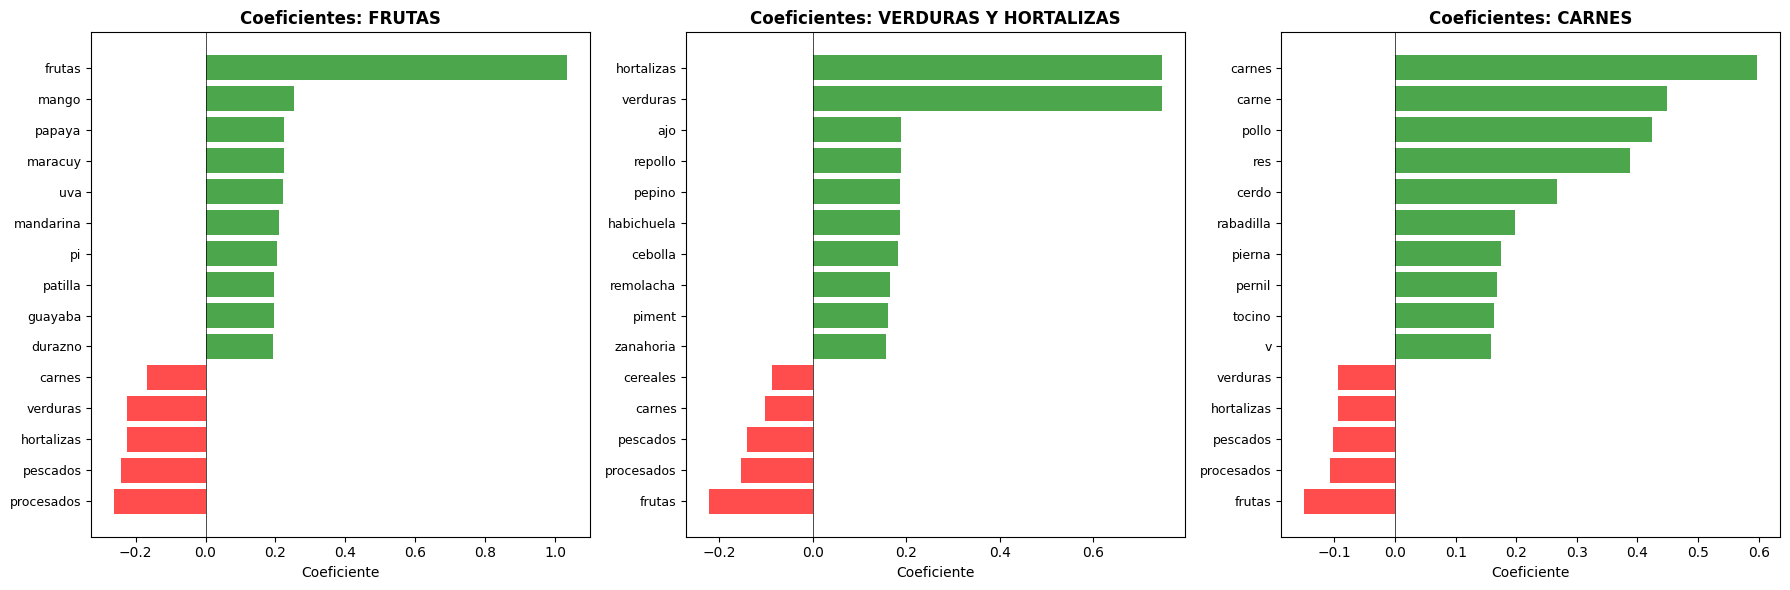

In [ ]:
# VISUALIZACIÓN OPCIONAL: Gráfico de coeficientes por clase

fig, axes = plt.subplots(1, min(3, len(coeficientes)), figsize=(18, 6))

for i, ax in enumerate(axes):
    cat_nombre = categorias_mapeo.get(float(i), f"Clase_{i}")

    # Top 10 positivos y 5 negativos
    top_pos = np.argsort(coeficientes[i])[-10:]
    top_neg = np.argsort(coeficientes[i])[:5]
    indices = np.concatenate([top_neg, top_pos])

    palabras = [vocab[idx] if idx < len(vocab) else f"idx_{idx}" for idx in indices]
    valores = [coeficientes[i][idx] for idx in indices]
    colores = ['red' if v < 0 else 'green' for v in valores]

    ax.barh(range(len(valores)), valores, color=colores, alpha=0.7)
    ax.set_yticks(range(len(valores)))
    ax.set_yticklabels(palabras, fontsize=9)
    ax.set_title(f'Coeficientes: {cat_nombre}', fontsize=12, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coeficiente')

plt.tight_layout()
plt.savefig('/content/coeficientes_nlp.png', dpi=150, bbox_inches='tight')
plt.show()

# PARTE D: MODELO PRE-ENTRENADO HUGGING FACE (Tareas 34-38)

In [ ]:
# ============================================
# TAREA 34-35: Cargar y aplicar modelo pre-entrenado
# ============================================

print("\n" + "=" * 70)
print("PARTE D - TAREAS 34-35: HUGGING FACE")
print("=" * 70)

# Modelo de sentimiento en español (recomendado por la guía)
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis",
    device=-1  # CPU
)

# Aplicar a muestra del corpus (CPU es lento, usar muestra pequeña)
muestra_hf = df_corpus.select("texto").sample(False, 0.01, seed=42).limit(200).toPandas()

print("⏳ Aplicando modelo pre-entrenado...")
resultados_hf = []
for texto in muestra_hf["texto"]:
    try:
        res = sentiment_pipeline(texto[:128])  # Truncar por límite del modelo
        resultados_hf.append({
            "texto": texto,
            "sentimiento": res[0]["label"],
            "score": res[0]["score"]
        })
    except:
        pass

df_pred_hf = pd.DataFrame(resultados_hf)
print(f"✅ Etiquetados con Hugging Face: {len(df_pred_hf)}")

# ============================================
# TAREA 36: Comparar TF-IDF vs Hugging Face
# ============================================

print("\n" + "=" * 70)
print("PARTE D - TAREA 36: COMPARACIÓN TF-IDF vs HUGGING FACE")
print("=" * 70)

print("""
COMPARACIÓN:
┌─────────────────┬──────────────────────┬──────────────────────┐
│ Aspecto         │ TF-IDF + LR          │ Hugging Face         │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Entrenamiento   │ Requiere datos       │ Pre-entrenado        │
│                 │ etiquetados          │                      │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Velocidad       │ Muy rápido           │ Lento (transformer)  │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Contexto        │ Bolsa de palabras    │ Contexto semántico   │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Interpretable   │ Sí (coeficientes)    │ No (caja negra)      │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Dominio         │ Específico (SIPSA)   │ Genérico (sentimiento│
│                 │                      │ en español)          │
└─────────────────┴──────────────────────┴──────────────────────┘
""")

# ============================================
# TAREA 37: Casos difíciles
# ============================================

print("\n" + "=" * 70)
print("PARTE D - TAREA 37: CASOS DIFÍCILES")
print("=" * 70)

casos_dificiles = [
    "pollo fresco barato pero de buena calidad",      # Contradicción
    "carne no es mala pero tampoco excelente",        # Negación + ambigüedad
    "papa pastusa grande pequeña",                     # Contradicción
    "plátano verde maduro para freír",                 # Oxímoron
    "tomate chonto verde no está caro"                 # Negación + contexto
]

print("\nProbando casos difíciles:")
for caso in casos_dificiles:
    res = sentiment_pipeline(caso[:128])
    print(f"\nTexto: {caso}")
    print(f"  Predicción: {res[0]['label']} (score: {res[0]['score']:.3f})")

# ============================================
# TAREA 38: Recomendación para producción
# ============================================

print("\n" + "=" * 70)
print("PARTE D - TAREA 38: RECOMENDACIÓN PARA PRODUCCIÓN")
print("=" * 70)

print("""
🏆 RECOMENDACIÓN PARA PRODUCCIÓN:

Para este dominio (precios agrícolas mayoristas), recomiendo un ENFOQUE HÍBRIDO:

1. FASE INICIAL: Usar Hugging Face para etiquetado automático de grandes
   volúmenes de texto (knowledge distillation).

2. FASE DE PRODUCCIÓN: Entrenar un modelo TF-IDF + Regresión Logística
   ligero con los datos etiquetados, por:
   - Velocidad de inferencia (milisegundos vs segundos)
   - Menor costo computacional
   - Interpretabilidad para validación de políticas públicas
   - Robustez ante vocabulario específico del sector agropecuario

3. MONITOREO: Re-entrenar periódicamente con nuevos datos del SIPSA
   para capturar cambios en el vocabulario del mercado.

RAZÓN: El dominio agropecuario colombiano tiene terminología muy específica
que un modelo genérico de sentimiento no captura completamente. Un modelo
entrenado in-domain con TF-IDF ofrece mejor precisión para clasificación
de productos y es suficiente para el volumen de datos del SIPSA.
""")


PARTE D - TAREAS 34-35: HUGGING FACE


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

⏳ Aplicando modelo pre-entrenado...
✅ Etiquetados con Hugging Face: 2

PARTE D - TAREA 36: COMPARACIÓN TF-IDF vs HUGGING FACE

COMPARACIÓN:
┌─────────────────┬──────────────────────┬──────────────────────┐
│ Aspecto         │ TF-IDF + LR          │ Hugging Face         │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Entrenamiento   │ Requiere datos       │ Pre-entrenado        │
│                 │ etiquetados          │                      │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Velocidad       │ Muy rápido           │ Lento (transformer)  │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Contexto        │ Bolsa de palabras    │ Contexto semántico   │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Interpretable   │ Sí (coeficientes)    │ No (caja negra)      │
├─────────────────┼──────────────────────┼──────────────────────┤
│ Dominio         │ Específico (SIPSA)   │ Genérico (sentimiento│
│ 

In [ ]:
import json
import os

# Ruta correcta (en la raíz de /content)
nb_path = "/content/proyecto_final_Velandia_Camilo/proyecto_final_Velandia_Camilo/bloque3_nlp/Proyecto_final_parte3.ipynb"  # o el nombre exacto

# Verificar si existe
if os.path.exists(nb_path):
    print(f"✅ Notebook encontrado en: {nb_path}")

    with open(nb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    # Limpiar metadata
    if 'metadata' in nb and 'widgets' in nb['metadata']:
        del nb['metadata']['widgets']

    for cell in nb.get('cells', []):
        if 'metadata' in cell and 'widgets' in cell['metadata']:
            del cell['metadata']['widgets']

    with open(nb_path, 'w', encoding='utf-8') as f:
        json.dump(nb, f, indent=1, ensure_ascii=False)

    print("✅ Notebook limpiado")

    # Mover a la carpeta del repo
    !cp "$nb_path" proyecto_final_Velandia_Camilo/bloque3_nlp/

else:
    print(f"❌ No se encontró: {nb_path}")
    print("   Usa el código de búsqueda arriba para encontrar la ruta correcta")

✅ Notebook encontrado en: /content/proyecto_final_Velandia_Camilo/proyecto_final_Velandia_Camilo/bloque3_nlp/Proyecto_final_parte3.ipynb
✅ Notebook limpiado
cp: cannot create regular file 'proyecto_final_Velandia_Camilo/bloque3_nlp/': No such file or directory
